In [13]:
import os
import pickle
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import eda

In [14]:
def load_items(stimuli_dir: Path, trial_id: int) -> np.ndarray:
    csv_path = stimuli_dir / f"civ_items_trial_{trial_id}.csv"
    df = pd.read_csv(csv_path)
    numeric = df.drop(columns=["Name"], errors="ignore")
    return numeric.to_numpy(dtype=np.int64)


def get_eda_params(items: np.ndarray) -> dict:
    n_obj = items.shape[1] - 1

    if n_obj == 3:
        n_selected = 6
        max_row_diff = 5
    elif n_obj == 5:
        n_selected = 10
        max_row_diff = 500
    else:
        raise ValueError(f"Number of objectives {n_obj} not supported")

    return {
        "n_items": items.shape[0],
        "n_obj": n_obj,
        "n_con": 1,
        "n_selected": n_selected,
        "capacity": n_selected * 10,
        "pop_size": 1_000,
        "generations": 100,
        "max_no_improve_gen": 5,
        "max_row_diff": max_row_diff,
    }


def aspi_to_p_rank(items: np.ndarray, n_obj: int, aspi_item: np.ndarray, temp: float = 0.3) -> np.ndarray:
    aspi_item = np.asarray(aspi_item, dtype=float)
    aspi_unit = aspi_item / (np.linalg.norm(aspi_item) + 1e-12)
    item_scores = items[:, :n_obj] @ aspi_unit
    ranks = item_scores.argsort().argsort().astype(float)
    scaled = ranks / (ranks.max() + 1e-12)
    logits = scaled / temp
    logits -= logits.max()
    p_rank = np.exp(logits)
    p_rank /= p_rank.sum()
    return p_rank


def run_eda_pass(items: np.ndarray, params: dict, p_rank: np.ndarray, seed: int) -> dict:
    eda_process = eda.KnapsackEDA(
        items=items,
        capacity=params["capacity"],
        n_selected=params["n_selected"],
        n_obj=params["n_obj"],
        pop_size=params["pop_size"],
        generations=params["generations"],
        max_no_improve_gen=params["max_no_improve_gen"],
        max_row_diff=params["max_row_diff"],
        seed=seed,
        p_rank=p_rank,
    )
    return eda_process.run()


def select_solutions(pf: np.ndarray, n_obj: int) -> tuple[np.ndarray, np.ndarray, float]:
    z_ideal = pf.max(axis=0)
    z_nadir = pf.min(axis=0)
    denom = z_ideal - z_nadir
    z_pf = (pf - z_nadir) / denom

    if not np.isfinite(z_pf).all():
        raise ValueError(
            "Invalid normalized Pareto front: z_pf contains NaN/Inf. "
        )

    z_center = np.median(z_pf, axis=0)
    z_dist = np.linalg.norm(z_pf - z_center, axis=1) 
    center_sol = pf[z_dist.argmin()]

    # percentile
    p90_list = [np.percentile(z_pf[:, i], 90) for i in range(n_obj)]
    extreme_sols = []
    for i in range(n_obj):
        diff_main = np.abs(z_pf[:, i] - p90_list[i])
        idx_all = np.where(diff_main == diff_main.min())[0]
        candidate_sols = pf[idx_all]
        candidate_sols_z = z_pf[idx_all]
        diff_others = []
        for j in range(n_obj):
            if j == i:
                continue
            # diff_other = np.abs(candidate_sols_z[:, j] - p90_list[j])
            diff_other = z_pf[:, j].max() - candidate_sols_z[:, j]
            diff_others.append(diff_other)
        diff_others = np.column_stack(diff_others)
        diff_others_sum = diff_others.sum(axis=1)
        idx_min_all = np.where(diff_others_sum == diff_others_sum.min())[0]
        if len(idx_min_all) > 1:
            warnings.warn(
            f"Multiple minima found for objective {i}: indices {idx_min_all}. Using the first one."
        )
        idx_min = idx_min_all[0] # extract a scalar no matter the number of minima
        sol = candidate_sols[idx_min]
        extreme_sols.append(sol)

    # extreme_sols = [pf[z_pf[:, i].argmax()] for i in range(n_obj)]

    selected_sols = np.array([*extreme_sols, center_sol])
    return selected_sols, center_sol, float(z_dist.min())


def compute_weighted_human_input(selected_sols: np.ndarray, ref_sol: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    dist = np.linalg.norm(selected_sols - ref_sol, axis=1)
    # inv_dist = 1.0 / (dist + 1e-12)
    # weights = inv_dist / inv_dist.sum()
    # new_aspi = weights @ selected_sols ## try weighted sum
    selected_sols_ranked = selected_sols[dist.argsort()]

    weights = 1.0 / np.linspace(1, np.exp(3), selected_sols.shape[0])
    weights /= weights.sum()
    new_aspi = weights @ selected_sols_ranked
    # new_aspi = selected_sols[dist.argmin()]
    return new_aspi, dist


def is_converged(center_sol: np.ndarray, ref_sol: np.ndarray, tolerance: float) -> bool:
    return np.linalg.norm(center_sol - ref_sol) < tolerance


def save_pass_results(results: dict, pass_idx: int, output_dir: Path, use_human_input: bool = True) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    result_type = "eda_human" if use_human_input else "eda"
    file_path = output_dir / f"{result_type}_pass{pass_idx}_90bestother_weighted_noinput.pkl"

    with open(file_path, "wb") as f:
        pickle.dump(results, f)

    return file_path

In [ ]:
# obtain item list
stimuli_dir = Path("card_game/stimuli")
trial_id = 8
items = load_items(stimuli_dir=stimuli_dir, trial_id=trial_id)

# hidden reference point (simulated human feedback)
ref_sol = np.array([76, 87, 92, 106, 82])

# run human guided EDA loop
params = get_eda_params(items)
n_obj = params["n_obj"]

if ref_sol.shape[0] != n_obj:
    raise ValueError(
        f"ref_sol has dimension {ref_sol.shape[0]}, expected {n_obj} to match n_obj"
    )

# random intial pass
rng = np.random.default_rng(15)
aspi_item = rng.integers(1, 150, size=n_obj)
p_rank = aspi_to_p_rank(items, n_obj, aspi_item, temp=0.3)
# p_rank = None
results = run_eda_pass(
    items=items,
    params=params,
    p_rank=p_rank,
    seed=1123,
)
pf = results["converged_pf_table"][-1]

history = []
max_passes = 5
tolerance = 10.0
eda_seed_start = 1124
output_dir = Path("data/eda_results")
temp = 0.3
for pass_idx in range(max_passes):
    selected_sols, center_sol, min_center_dist = select_solutions(pf, n_obj)
    aspi_sol, dist_to_ref = compute_weighted_human_input(selected_sols, ref_sol)
    p_rank = aspi_to_p_rank(items, n_obj, aspi_sol, temp=temp)

    results = run_eda_pass(
        items=items,
        params=params,
        p_rank=p_rank,
        seed=eda_seed_start + pass_idx,
    )
    save_path = save_pass_results(results, pass_idx, output_dir, use_human_input=(p_rank is not None))
    pf = results["converged_pf_table"][-1]

    pass_record = {
        "pass_idx": pass_idx,
        "save_path": str(save_path),
        "center_solution": center_sol, 
        "selected_solutions": selected_sols, 
        "aspi_solution": aspi_sol,
        "distance_selected_to_ref": dist_to_ref,
        "min_normalized_center_distance": min_center_dist,
    }
    history.append(pass_record)
    print(
        f"Pass {pass_idx}: min_center_dist={min_center_dist:.4f}, "
        f"center_to_ref={np.linalg.norm(center_sol - ref_sol):.4f}, "
    )

with open('data/eda_results/history_90bestother_weighted_2.pkl', 'wb') as f:
    pickle.dump(history, f)

75_best / 90_best / 100_best / 90_weighted: [79, 89, 146, 71, 70]
100_best_2 : [76, 87, 92, 106, 82]

In [ ]:
# with open('data/eda_results/history_90bestother_best.pkl', 'rb') as f:
#     history = pickle.load(f)
# ref_sol = np.array([79, 89, 146, 71, 70])
aspi_sol_list = []
selected_sols_list = []

aspi_sol_list = []
for i in range(max_passes):
    history_pass = history[i]
    aspi_sol = history_pass['aspi_solution']
    aspi_sol_list.append(aspi_sol)
    selected_sols = history_pass['selected_solutions']
    selected_sols_list.append(selected_sols)

    print(np.linalg.norm(aspi_sol - ref_sol))

20.83266665599966
23.323807579381203
18.841443681416774
13.711309200802088
18.841443681416774


In [ ]:
# with open('card_game/eda_results/eda_trial8.pkl', 'rb') as f:
#     results = pickle.load(f)
# pf_actual = results['converged_pf_table'][-1]

In [ ]:
# from matplotlib import pyplot as plt
# %matplotlib widget
# from mpl_toolkits.mplot3d import Axes3D

# ref_sol = np.array([79, 89, 146, 71, 70])
# for i in range(5):
#     with open(f'data/eda_results/eda_human_pass{i}.pkl', 'rb') as f:
#         results = pickle.load(f)
#     pf = results["converged_pf_table"][-1]
#     fig = plt.figure(figsize=(10, 10))
#     # ax = fig.add_subplot()
#     ax = fig.add_subplot(projection='3d')
#     ax.plot(pf_actual[:,2], pf_actual[:,3], pf_actual[:,4], 'go', alpha=0.5, markersize=3)
#     ax.plot(pf[:,2], pf[:,3], pf[:,4], 'bo', alpha=0.5, markersize=3)
#     ax.plot(ref_sol[2], ref_sol[3], ref_sol[4], 'rs', alpha=1, markersize=5)
#     ax.set_xlabel('Obj 3')
#     ax.set_ylabel('Obj 4')
#     ax.set_zlabel('Obj 5')
#     plt.show()

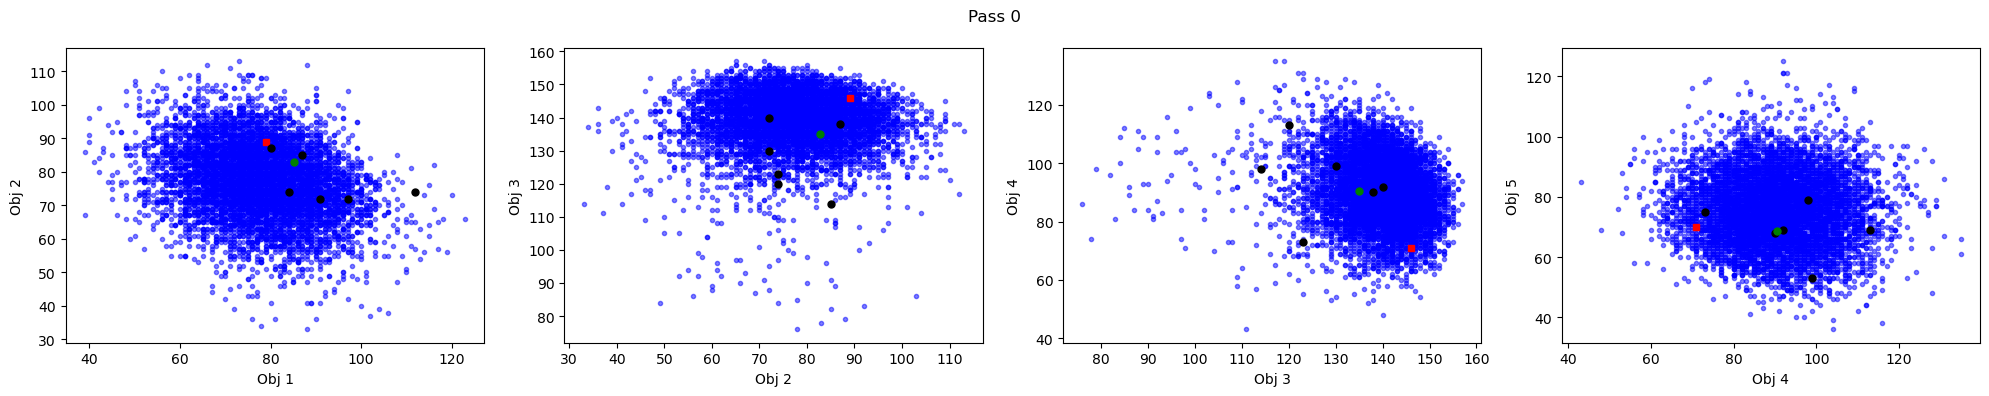

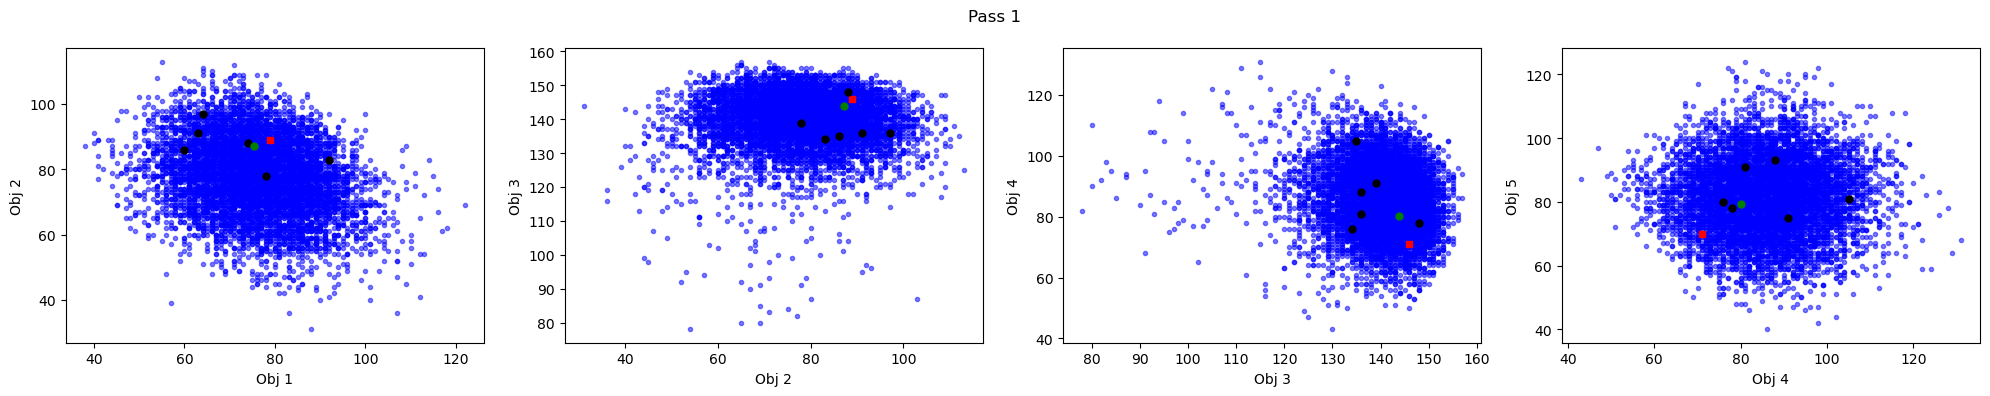

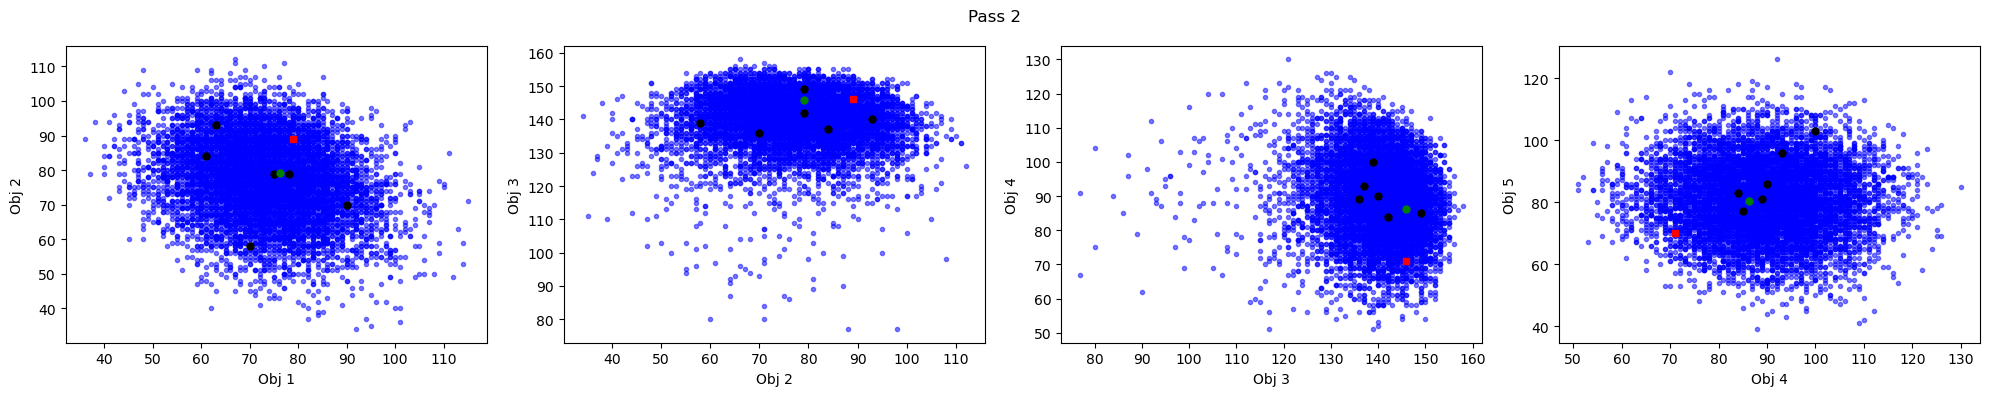

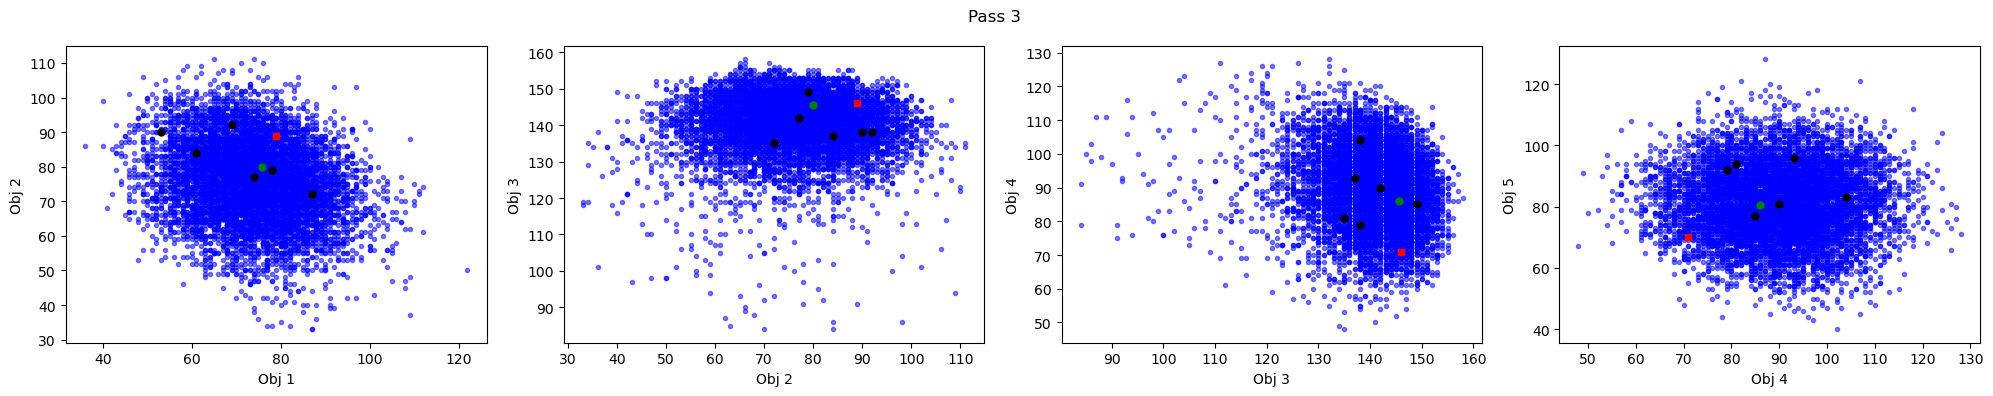

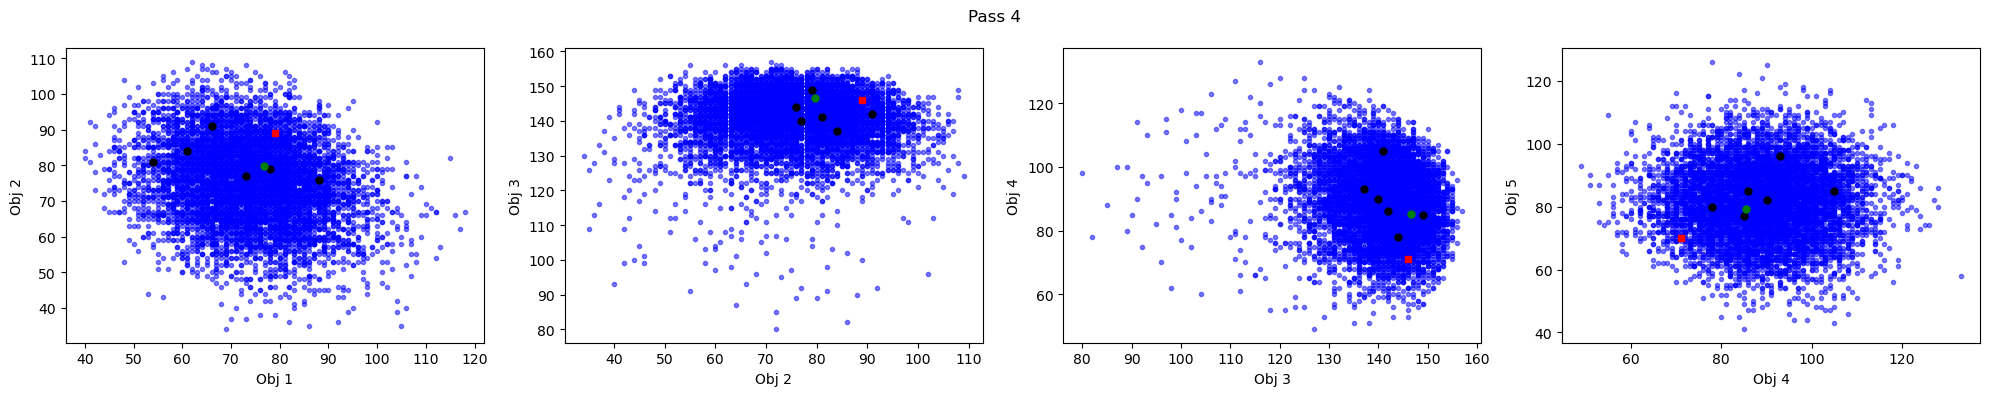

In [ ]:
from matplotlib import pyplot as plt

for i in range(max_passes):
    with open(f'data/eda_results/eda_human_pass{i}_90bestother_weighted_2.pkl', 'rb') as f:
        results = pickle.load(f)

    pf = results["converged_pf_table"][-1]

    fig = plt.figure(figsize=(20, 4))
    ax0 = fig.add_subplot(1, 4, 1)
    ax1 = fig.add_subplot(1, 4, 2)
    ax2 = fig.add_subplot(1, 4, 3)
    ax3 = fig.add_subplot(1, 4, 4)

    # ax0.plot(pf_actual[:, 3], pf_actual[:, 0], 'go', alpha=0.5, markersize=3)
    ax0.plot(pf[:, 0], pf[:, 1], 'bo', alpha=0.5, markersize=3)
    ax0.plot(ref_sol[0], ref_sol[1], 'rs', alpha=1, markersize=5)
    ax0.plot(selected_sols_list[i][:, 0], selected_sols_list[i][:, 1], 'ko', alpha=1, markersize=5)
    ax0.plot(aspi_sol_list[i][0], aspi_sol_list[i][1], 'go', alpha=1, markersize=5)
    ax0.set_xlabel('Obj 1')
    ax0.set_ylabel('Obj 2')
    # ax0.set_ylim(30, 120)
    # ax0.set_xlim(35, 125)

    # ax1.plot(pf_actual[:, 3], pf_actual[:, 1], 'go', alpha=0.5, markersize=3)
    ax1.plot(pf[:, 1], pf[:, 2], 'bo', alpha=0.5, markersize=3)
    ax1.plot(ref_sol[1], ref_sol[2], 'rs', alpha=1, markersize=5)
    ax1.plot(selected_sols_list[i][:, 1], selected_sols_list[i][:, 2], 'ko', alpha=1, markersize=5)
    ax1.plot(aspi_sol_list[i][1], aspi_sol_list[i][2], 'go', alpha=1, markersize=5)
    ax1.set_xlabel('Obj 2')
    ax1.set_ylabel('Obj 3')
    # ax1.set_ylim(75, 160)
    # ax1.set_xlim(25, 120)

    # ax2.plot(pf_actual[:, 3], pf_actual[:, 2], 'go', alpha=0.5, markersize=3)
    ax2.plot(pf[:, 2], pf[:, 3], 'bo', alpha=0.5, markersize=3)
    ax2.plot(ref_sol[2], ref_sol[3], 'rs', alpha=1, markersize=5)
    ax2.plot(selected_sols_list[i][:, 2], selected_sols_list[i][:, 3], 'ko', alpha=1, markersize=5)
    ax2.plot(aspi_sol_list[i][2], aspi_sol_list[i][3], 'go', alpha=1, markersize=5)
    ax2.set_xlabel('Obj 3')
    ax2.set_ylabel('Obj 4')
    # ax2.set_ylim(35, 135)
    # ax2.set_xlim(70, 160)

    # ax3.plot(pf_actual[:, 3], pf_actual[:, 4], 'go', alpha=0.5, markersize=3)
    ax3.plot(pf[:, 3], pf[:, 4], 'bo', alpha=0.5, markersize=3)
    ax3.plot(ref_sol[3], ref_sol[4], 'rs', alpha=1, markersize=5)
    ax3.plot(selected_sols_list[i][:, 3], selected_sols_list[i][:, 4], 'ko', alpha=1, markersize=5)
    ax3.plot(aspi_sol_list[i][3], aspi_sol_list[i][4], 'go', alpha=1, markersize=5)
    ax3.set_xlabel('Obj 4')
    ax3.set_ylabel('Obj 5')
    # ax3.set_ylim(35, 125)
    # ax3.set_xlim(35, 140)

    fig.suptitle(f'Pass {i}')
    fig.tight_layout()
    plt.show()

In [ ]:
plt.close()